In [4]:
import os, re, random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import norm, gaussian_kde
from scipy.optimize import curve_fit, minimize
from scipy.signal import argrelextrema
from tqdm import tqdm
import pandas as pd
from math import factorial

rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [11, 8]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 16
rcParams['ytick.labelsize'] = 16

# FUNCTIONS (UPDATED FOR MULTI-PE)

def do_pulse_finding(waveform, debug=False):
    threshold = 20
    fIntegralPreceding = 4
    fIntegralFollowing = 2
    
    above_threshold = np.where(waveform[3:-2] > threshold)[0] + 3
    pulses_found = []
    last_index = 0
    
    for index in above_threshold:
        if (waveform[index] <= waveform[index-1]): continue
        if (waveform[index] < waveform[index+1]): continue
        if (waveform[index] <= waveform[index+2]): continue
        if (waveform[index] <= waveform[index-2]): continue
        
        start = max(0, index - fIntegralPreceding)
        end = min(len(waveform), index + fIntegralFollowing + 1)
        integral = np.sum(waveform[start:end])
        if integral < threshold * 2:
            continue
        
        if (last_index > 0) and (index - last_index) <= 20:
            continue
        
        pulses_found.append(index)
        last_index = index
    
    return pulses_found


def charge_calculation_mPMT_method(wf, peak_sample):
    n = len(wf)
    start = max(0, peak_sample - 5)
    end = min(n, peak_sample + 2)
    charge = np.sum(wf[start:end])
    if peak_sample + 2 < n and wf[peak_sample + 2] > 0:
        charge += wf[peak_sample + 2]
    return charge


# ----------------------------------
# SAFE Gaussian fit (NO HARD FAIL)
# ----------------------------------
def fit_gaussian_with_bounds(data, mu0, sigma0, sigma_bounds):

    N = len(data)
    if N < 10:
        return dict(
            mu=np.median(data) if N > 0 else 0.0,
            sigma=np.std(data) if N > 1 else 1.0,
            A=N,
            err_mu=np.inf,
            err_sigma=np.inf,
            n=N,
            failed=True
        )

    A0 = N
    bounds = [(-np.inf, np.inf), sigma_bounds, (1, np.inf)]

    def nll(params):
        mu, sigma, A = params
        if sigma <= 0 or A <= 0:
            return np.inf
        pdf = A * norm.pdf(data, mu, sigma)
        return -np.sum(np.log(np.clip(pdf, 1e-12, None)))

    res = minimize(nll, [mu0, sigma0, A0], method="L-BFGS-B", bounds=bounds)

    if not res.success:
        return dict(
            mu=np.median(data),
            sigma=np.std(data),
            A=N,
            err_mu=np.inf,
            err_sigma=np.inf,
            n=N,
            failed=True
        )

    mu_fit, sigma_fit, A_fit = res.x
    return dict(
        mu=mu_fit,
        sigma=sigma_fit,
        A=A_fit,
        err_mu=sigma_fit / np.sqrt(N),
        err_sigma=sigma_fit / np.sqrt(2*N),
        n=N,
        failed=False
    )


# ----------------------------------
# Pedestal + SPE (NO HARD FAIL)
# ----------------------------------
def fit_pedestal_and_spe(charges, label="PMT", plot=True):

    x = np.asarray(charges)
    if len(x) < 80:
        return None

    xs = np.linspace(np.min(x), np.max(x), 2500)
    kde = gaussian_kde(x)
    ys = kde(xs)
    peak_idx = argrelextrema(ys, np.greater)[0]

    ped_center = 0.0
    spe_center = None

    try:
        expected_spe_min = 50
        expected_spe_max = 250.0
        peak_xs = xs[peak_idx]
        peak_ys = ys[peak_idx]

        spe_mask = (peak_xs >= expected_spe_min) & (peak_xs <= expected_spe_max)
        spe_idx = np.where(spe_mask)[0]

        if len(spe_idx) > 0:
            i = spe_idx[np.argmax(peak_ys[spe_idx])]
            spe_center = peak_xs[i]
            ped_center = np.min(peak_xs[peak_xs < spe_center])
        else:
            raise RuntimeError

    except Exception:
        spe_candidates = x[(x >= 100) & (x <= 200)]
        if len(spe_candidates) == 0:
            return None
        spe_center = np.median(spe_candidates)
        ped_center = 0.0

    ped_mask = np.abs(x - ped_center) < 10
    ped_data = x[ped_mask]

    spe_mask = np.abs(x - spe_center) < 60
    spe_data = x[spe_mask]

    if len(spe_data) < 20:
        return None

    pedestal_fit = fit_gaussian_with_bounds(
        ped_data,
        np.median(ped_data) if len(ped_data) else 0.0,
        np.std(ped_data) if len(ped_data) > 1 else 1.0,
        (0.1, 10.0)
    )

    spe_fit = fit_gaussian_with_bounds(
        spe_data,
        np.median(spe_data),
        max(20, np.std(spe_data)),
        (5, 300)
    )

    gain = spe_fit["mu"] - ped_center
    err_gain = np.sqrt(
        (pedestal_fit["err_mu"] if np.isfinite(pedestal_fit["err_mu"]) else 0)**2 +
        spe_fit["err_mu"]**2
    )

    result = dict(
        pedestal=pedestal_fit,
        spe=spe_fit,
        gain=gain,
        err_gain=err_gain,
        n_ped=len(ped_data),
        n_spe=len(spe_data)
    )

    if plot:
        bins = np.linspace(np.min(x), np.max(x), 100)
        bc = 0.5*(bins[1:] + bins[:-1])
        bw = bins[1] - bins[0]
        fig, ax = plt.subplots(figsize=(9,6), dpi=150)
        ax.hist(x, bins=bins, histtype="step", color="black", lw=1, label="Data")
        ped_pdf = pedestal_fit["n"] * norm.pdf(bc, pedestal_fit["mu"], pedestal_fit["sigma"]) * bw
        spe_pdf  = spe_fit["n"] * norm.pdf(bc,  spe_fit["mu"],  spe_fit["sigma"]) * bw
        ax.plot(bc, ped_pdf, "b--", lw=1.5, label=f"Pedestal μ={pedestal_fit['mu']:.2f}, σ={pedestal_fit['sigma']:.2f}, N={len(ped_data)}")
        ax.plot(bc, spe_pdf,  "g--", lw=1.5, label=f"SPE μ={spe_fit['mu']:.2f}, σ={spe_fit['sigma']:.2f}, N={len(spe_data)}")
        ax.plot(bc, ped_pdf + spe_pdf, "r", lw=1, alpha=0.7, label=f"Sum (Gain = {gain:.2f} ± {err_gain:.2f})")
        ax.set_xlim(-20, 500)
        ax.set_ylim(0, 300)
        ax.set_xlabel("Integrated charge [ADC·ns]")
        ax.set_ylabel(f"counts / {bw:.2f} ADC·ns")
        ax.set_title(f"Run {run_number}, pulse width {pulse_width}ps - PMT {pmt_label}: Unbinned Gaussian fit for seeds")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=rcParams['legend.fontsize'])
        plt.show()

    return result


# ===============================
# MULTI-PE SEQUENTIAL FIT
# ===============================

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def fit_multi_pe_sequential(charges, seeds, n_max=5, bins=500, plot=True):
    """
    Sequential multi-PE fit.
    - Pedestal and SPE fitted first independently.
    - Higher PE peaks fitted sequentially.
    - Fit windows are centered on n*mu_SPE, allow overlap.
    - Red line = sum of individual Gaussian fits only.
    """
    x = np.asarray(charges)
    counts, edges = np.histogram(x, bins=bins)
    bin_centers = 0.5*(edges[1:] + edges[:-1])
    bw = bin_centers[1] - bin_centers[0]

    mu_ped, sigma_ped = seeds['pedestal']['mu'], seeds['pedestal']['sigma']
    mu_spe, sigma_spe = seeds['spe']['mu'], seeds['spe']['sigma']

    peaks = {}  # store (mu, sigma, A) for each n-PE

    # Helper: safe Gaussian fit
    def safe_fit(x_fit, y_fit, p0, bounds):
        try:
            params, _ = curve_fit(gaussian, x_fit, y_fit, p0=p0, bounds=bounds, maxfev=20000)
        except:
            params = p0
        A_fit, mu_fit, sigma_fit = params
        return mu_fit, sigma_fit, A_fit

    # 0-PE
    mask0 = (bin_centers >= mu_ped - 3*sigma_ped) & (bin_centers <= mu_ped + 3*sigma_ped)
    x0, y0 = bin_centers[mask0], counts[mask0]
    mu0_fit, sigma0_fit, A0 = safe_fit(x0, y0, [np.max(y0), mu_ped, sigma_ped],
                                       bounds=([0, mu_ped-5*sigma_ped, 0.05],
                                               [np.inf, mu_ped+5*sigma_ped, 10]))
    peaks[0] = (mu0_fit, sigma0_fit, A0)

    # 1-PE
    mask1 = (bin_centers >= mu_spe - 1.5*sigma_spe) & (bin_centers <= mu_spe + 1.5*sigma_spe)
    x1, y1 = bin_centers[mask1], counts[mask1]
    mu1_fit, sigma1_fit, A1 = safe_fit(x1, y1, [np.max(y1), mu_spe, sigma_spe],
                                       bounds=([0, mu_spe-3*sigma_spe, 5],
                                               [np.inf, mu_spe+3*sigma_spe, 80]))
    peaks[1] = (mu1_fit, sigma1_fit, A1)

    # n-PE peaks (n>=2)
    for n in range(2, n_max+1):
        mu_n_seed = n * mu1_fit
        sigma_n_seed = np.sqrt(n) * sigma1_fit
        low, high = mu_n_seed - np.sqrt(n)*sigma1_fit, mu_n_seed + np.sqrt(n)*sigma1_fit  # centered window
        mask_n = (bin_centers >= low) & (bin_centers <= high)
        x_n, y_n = bin_centers[mask_n], counts[mask_n]

        if len(x_n) > 0:
            mu_n_fit, sigma_n_fit, A_n = safe_fit(
                x_n, y_n, [np.max(y_n), mu_n_seed, sigma_n_seed],
                bounds=([0, mu_n_seed-0.5*sigma1_fit, 0.1],
                        [np.inf, mu_n_seed+0.5*sigma1_fit, 150])
            )
        else:
            mu_n_fit, sigma_n_fit, A_n = mu_n_seed, sigma_n_seed, 0
        peaks[n] = (mu_n_fit, sigma_n_fit, A_n)

    # PLOTTING
    if plot:
        xx = np.linspace(-20, 1000, 100)
        plt.figure(figsize=(9,6), dpi=150)
        plt.hist(x, bins=bins, histtype='step', color='black', lw=1, alpha=0.8, label='Data')

        colors_list = ['blue','cyan','orange','purple','brown','green']
        total_fit_curve = np.zeros_like(xx)

        for i, (n, (mu, sigma, A)) in enumerate(peaks.items()):
            y_curve = gaussian(xx, A, mu, sigma)
            plt.plot(xx, y_curve, '--', color=colors_list[i % len(colors_list)],
                     lw=1.5, label=f"{n}-PE μ={mu:.2f}, σ={sigma:.2f}")
            plt.axvspan(mu-2.5*sigma, mu+2.5*sigma, alpha=0.08, color=colors_list[i % len(colors_list)])
            total_fit_curve += y_curve  # just sum Gaussians

        plt.plot(xx, total_fit_curve, 'r-', lw=1, label='Sum of Gaussian fits')
        plt.xlabel('Integrated charge [ADC·ns]')
        plt.ylabel(f'counts / {bw:.2f} ADC·ns')
        plt.xlim(-20, 1000)
        plt.ylim(0, 150)
        plt.grid(alpha=0.3)
        plt.legend(fontsize=rcParams['legend.fontsize'])
        plt.title(f'Run {run_number} – PMT {pmt_label}. Multi-PE fit')
        plt.show()

    return peaks

In [5]:
signal_dir = "/scratch/elena/WCTE_DATA_ANALYSIS/waveform_npz/run2307"
pattern = re.compile(r"card(\d+)_slot(\d+)_ch(\d+)_pos(\d+)\.npz$")
PULSE_RATIO_THRESHOLD = 0.3  # roughly corresponds to mu_pe ~ 0.5


available_pmts = []
for fname in os.listdir(signal_dir):
    match = pattern.match(fname)
    if match:
        available_pmts.append(tuple(map(int, match.groups())))

available_pmts = sorted(available_pmts)
print(f"Found {len(available_pmts)} PMT files.")


best_ratio = 0
best_pmt = None

for card_id, slot_id, ch_id, pos_id in available_pmts:

    combined_file = os.path.join(signal_dir, f"card{card_id}_slot{slot_id}_ch{ch_id}_pos{pos_id}.npz")
    data = np.load(combined_file, allow_pickle=True)
    signal_waveforms = data["waveforms"]

    # Pulse finding
    all_peaks = [do_pulse_finding(wf) for wf in signal_waveforms]
    pulse_mask = np.array([len(p)>0 for p in all_peaks])
    pulse_ratio = np.sum(pulse_mask) / len(signal_waveforms)

    if pulse_ratio >= PULSE_RATIO_THRESHOLD:
        pmt_label = f"card{card_id}_slot{slot_id}_ch{ch_id}"
        print(f"Try PMT {pmt_label}, with pulse_ratio = {pulse_ratio:.4f}")
        break

    # keep track of brightest PMT in case no PMT passes the threshold
    if pulse_ratio > best_ratio:
        best_ratio = pulse_ratio
        best_pmt = (card_id, slot_id, ch_id, pos_id)

else:
    # fallback
    card_id, slot_id, ch_id, pos_id = best_pmt
    pmt_label = f"card{card_id}_slot{slot_id}_ch{ch_id}"
    combined_file = os.path.join(signal_dir, f"card{card_id}_slot{slot_id}_ch{ch_id}_pos{pos_id}.npz")
    data = np.load(combined_file, allow_pickle=True)
    signal_waveforms = data["waveforms"]
    print(f"No PMT reached pulse_ratio {PULSE_RATIO_THRESHOLD}, fallback to brightest: {pmt_label}, pulse_ratio={best_ratio:.4f}")



all_peaks = [do_pulse_finding(wf) for wf in signal_waveforms]
pulse_mask = np.array([len(p)>0 for p in all_peaks])
noise_mask = ~pulse_mask

charges = []
peak_values = []

for wf, peaks in tqdm(zip(signal_waveforms, all_peaks), total=len(signal_waveforms), desc="Integrating waveforms"):
    peak_sample = peaks[0] if len(peaks)>0 else np.argmax(wf)
    charges.append(charge_calculation_mPMT_method(wf, peak_sample))
    peak_values.append(wf[peak_sample])

charges = np.array(charges)
peak_values = np.array(peak_values)

pulse_count = np.sum(pulse_mask)
noise_count = np.sum(noise_mask)
pulse_ratio = pulse_count / len(signal_waveforms)
mu_pe = -np.log(1 - pulse_ratio)

run_number = int(re.search(r"run(\d+)", signal_dir).group(1))
pulse_width = 810

print(f"Selected PMT: {pmt_label}")
print(f"Total waveforms: {len(signal_waveforms)} | Pulses: {pulse_count} | Noise: {noise_count} | pulse_ratio={pulse_ratio:.4f} | mu_pe={mu_pe:.4f}")

Found 1567 PMT files.
Try PMT card74_slot0_ch1, with pulse_ratio = 0.3265


Integrating waveforms: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:00<00:00, 35729.65it/s]

Selected PMT: card74_slot0_ch1
Total waveforms: 6000 | Pulses: 1959 | Noise: 4041 | pulse_ratio=0.3265 | mu_pe=0.3953


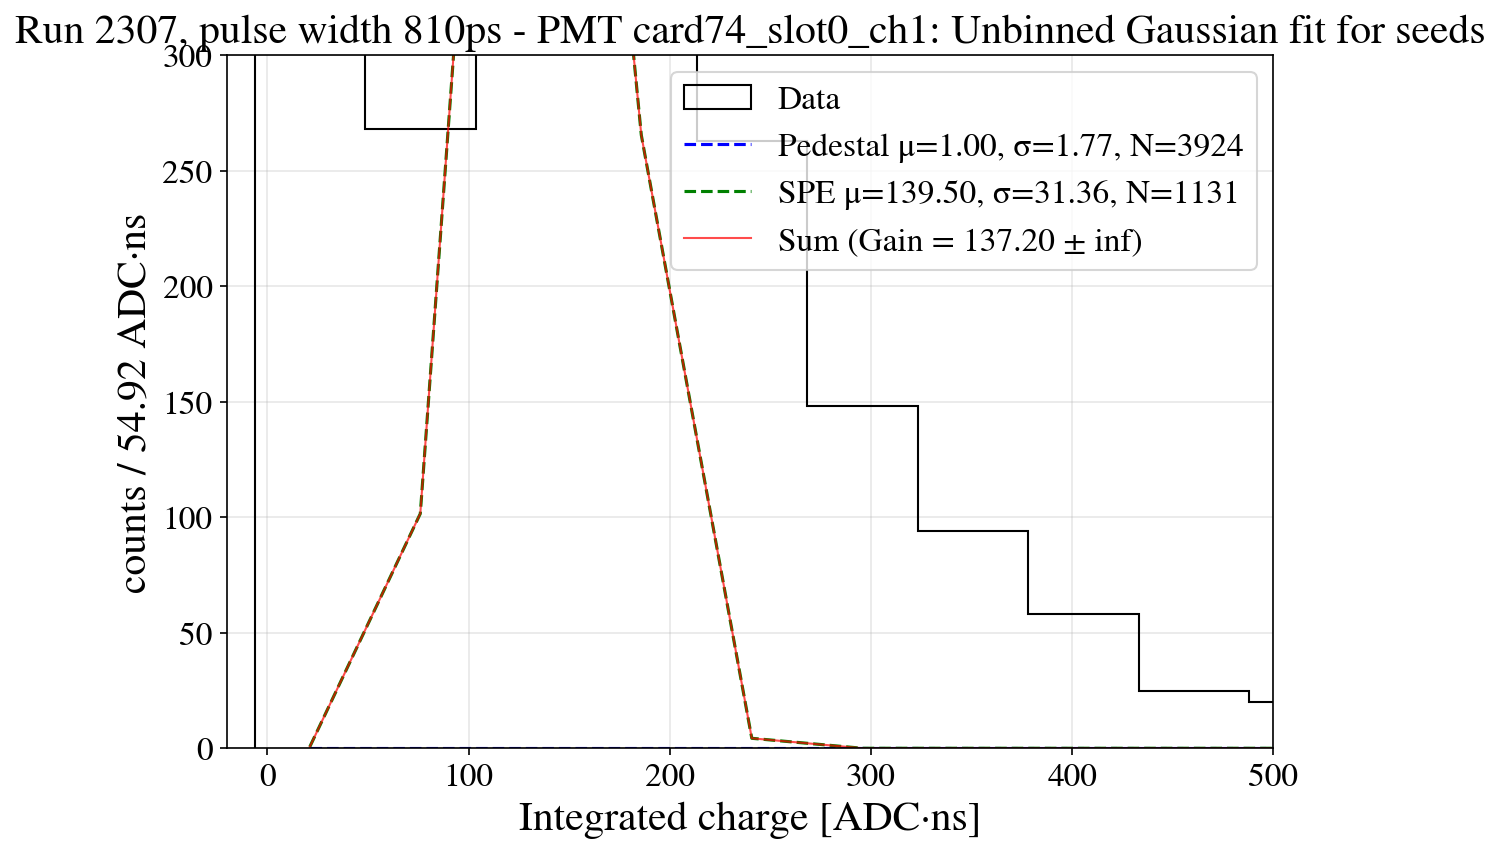

Pedestal: mu=1.00, sigma=1.77
SPE: mu=139.50, sigma=31.36, Gain=137.20 ± inf


/dipc/elena/.local/lib/python3.7/site-packages/scipy/optimize/minpack.py:834: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


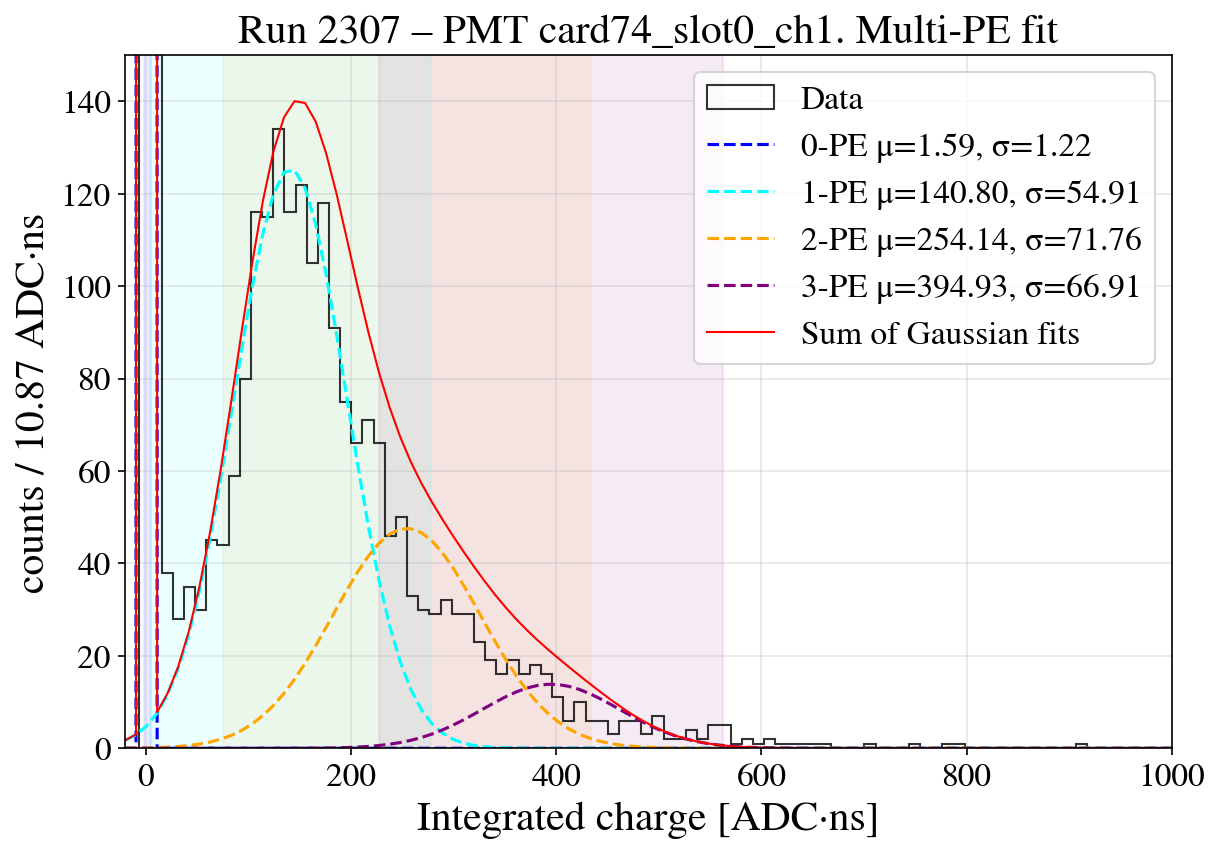


=== FINAL MULTI-PE FIT RESULTS ===
0-PE: mu=1.59, sigma=1.22, N=98807
1-PE: mu=140.80, sigma=54.91, N=17269
2-PE: mu=254.14, sigma=71.76, N=8563
3-PE: mu=394.93, sigma=66.91, N=2324


In [7]:

# ===================== CALCULAR SEEDS ========================
seeds = fit_pedestal_and_spe(charges, label=pmt_label, plot=True)

if seeds is None:
    raise RuntimeError("No se pudieron calcular las seeds para pedestal/SPE.")

print(f"Pedestal: mu={seeds['pedestal']['mu']:.2f}, sigma={seeds['pedestal']['sigma']:.2f}")
print(f"SPE: mu={seeds['spe']['mu']:.2f}, sigma={seeds['spe']['sigma']:.2f}, Gain={seeds['gain']:.2f} ± {seeds['err_gain']:.2f}")

# ==================== MULTI-PE GLOBAL FIT =====================
n_max_pe = 3
multi_pe_results = fit_multi_pe_sequential(charges, seeds, n_max=n_max_pe, bins=500, plot=True)

# Filtramos picos con N>0 para reportarlos
print("\n=== FINAL MULTI-PE FIT RESULTS ===")
for n, (mu, sigma, A) in multi_pe_results.items():
    N_events = int(A * sigma * np.sqrt(2*np.pi))
    if N_events > 0:
        print(f"{n}-PE: mu={mu:.2f}, sigma={sigma:.2f}, N={N_events}")


Found 1567 PMT files.

Processing PMT card74_slot0_ch1 with pulse_ratio=0.3265


Integrating waveforms for card74_slot0_ch1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:00<00:00, 35803.00it/s]


Total waveforms: 6000 | Pulses: 1959 | Noise: 4041 | mu_pe=0.3953
Pedestal: mu=1.00, sigma=1.77
SPE: mu=139.50, sigma=31.36, Gain=137.20 ± inf


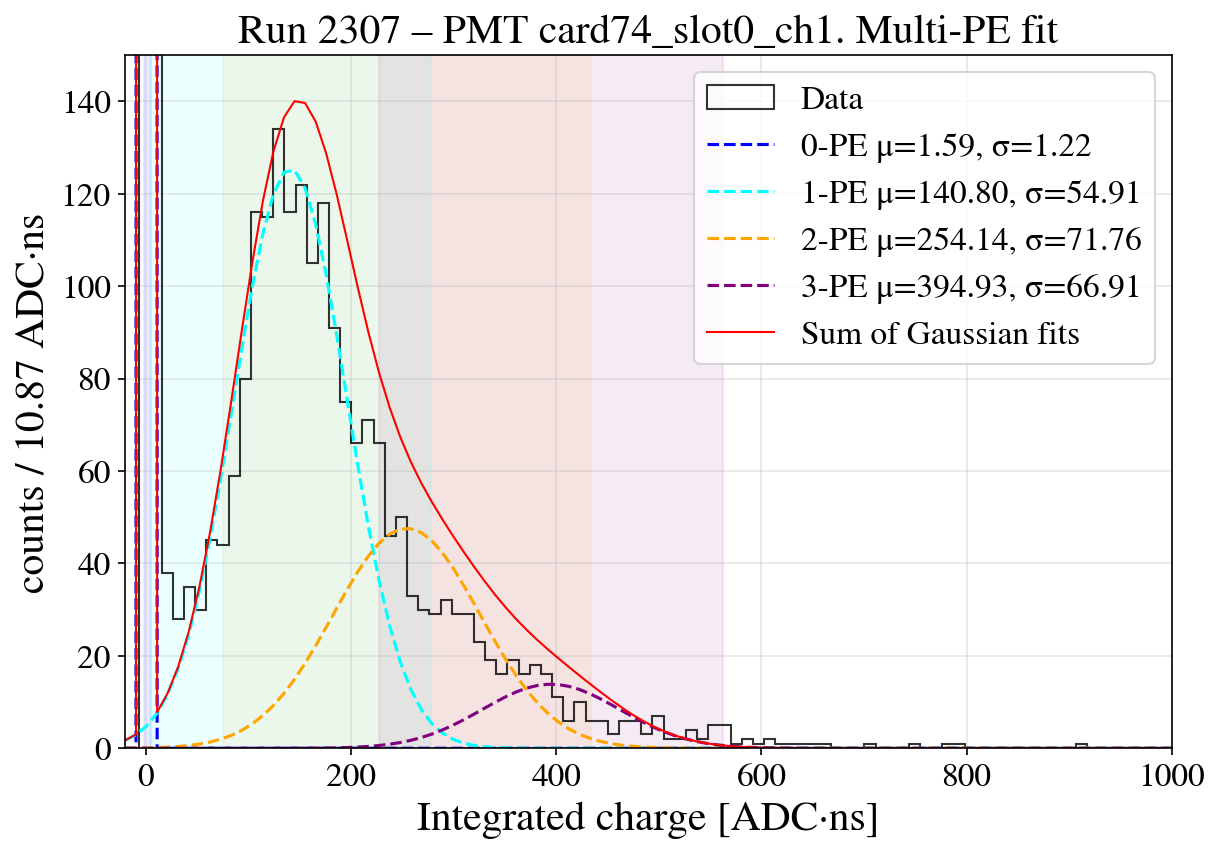


=== FINAL MULTI-PE FIT RESULTS ===
0-PE: mu=1.59, sigma=1.22, N=98807
1-PE: mu=140.80, sigma=54.91, N=17269
2-PE: mu=254.14, sigma=71.76, N=8563
3-PE: mu=394.93, sigma=66.91, N=2324

Processing PMT card74_slot0_ch2 with pulse_ratio=0.3413


Integrating waveforms for card74_slot0_ch2: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:00<00:00, 36457.84it/s]


Total waveforms: 6000 | Pulses: 2048 | Noise: 3952 | mu_pe=0.4175
Pedestal: mu=0.80, sigma=1.51
SPE: mu=153.90, sigma=31.95, Gain=152.42 ± inf


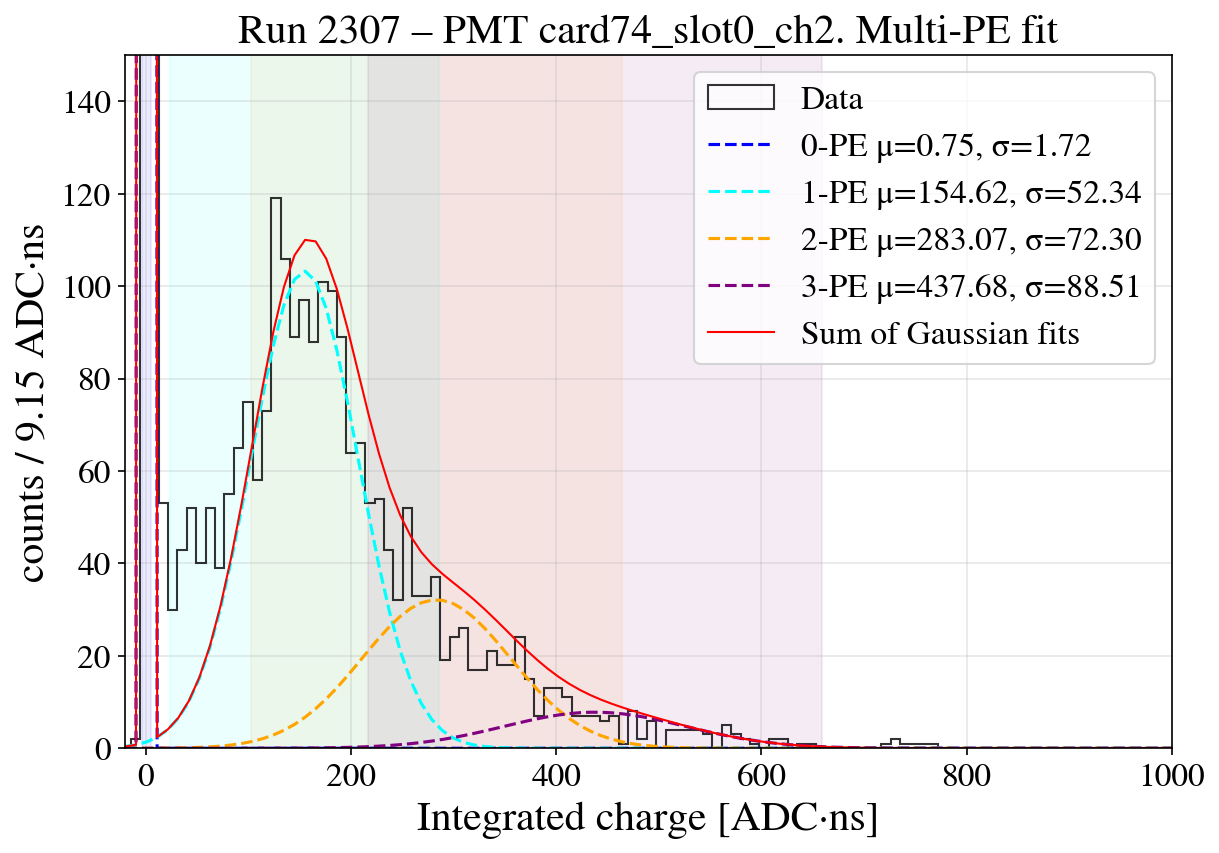


=== FINAL MULTI-PE FIT RESULTS ===
0-PE: mu=0.75, sigma=1.72, N=29827
1-PE: mu=154.62, sigma=52.34, N=13548
2-PE: mu=283.07, sigma=72.30, N=5823
3-PE: mu=437.68, sigma=88.51, N=1731

Processing PMT card74_slot0_ch4 with pulse_ratio=0.3418


Integrating waveforms for card74_slot0_ch4: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:00<00:00, 36282.80it/s]


Total waveforms: 6000 | Pulses: 2051 | Noise: 3949 | mu_pe=0.4183
Pedestal: mu=0.80, sigma=1.65
SPE: mu=148.95, sigma=31.80, Gain=148.06 ± inf


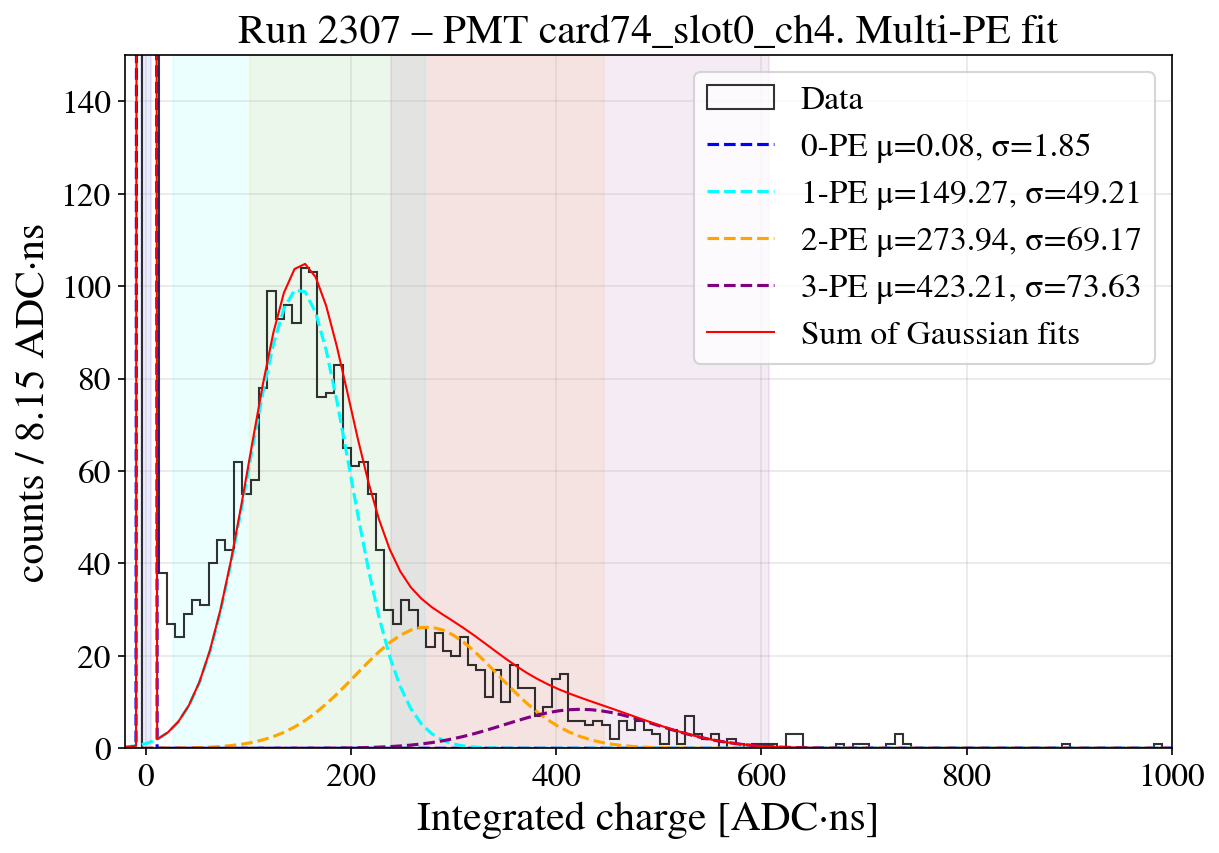


=== FINAL MULTI-PE FIT RESULTS ===
0-PE: mu=0.08, sigma=1.85, N=16405
1-PE: mu=149.27, sigma=49.21, N=12277
2-PE: mu=273.94, sigma=69.17, N=4550
3-PE: mu=423.21, sigma=73.63, N=1555

Processing PMT card74_slot0_ch7 with pulse_ratio=0.3335


Integrating waveforms for card74_slot0_ch7: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:00<00:00, 36510.94it/s]


Total waveforms: 6000 | Pulses: 2001 | Noise: 3999 | mu_pe=0.4057
Pedestal: mu=0.80, sigma=1.37
SPE: mu=143.30, sigma=33.18, Gain=142.28 ± inf


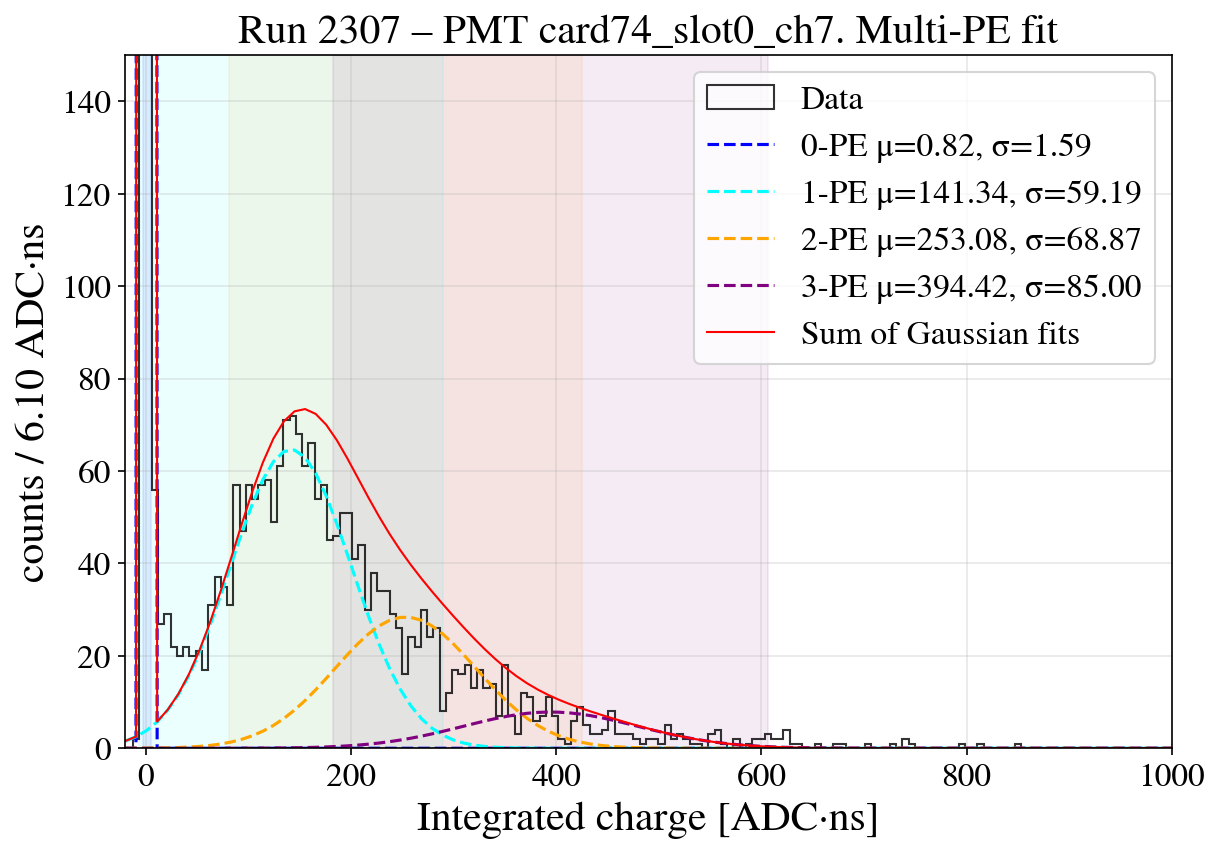


=== FINAL MULTI-PE FIT RESULTS ===
0-PE: mu=0.82, sigma=1.59, N=31390
1-PE: mu=141.34, sigma=59.19, N=9594
2-PE: mu=253.08, sigma=68.87, N=4903
3-PE: mu=394.42, sigma=85.00, N=1670

Processing PMT card74_slot0_ch9 with pulse_ratio=0.3357


Integrating waveforms for card74_slot0_ch9: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:00<00:00, 35862.55it/s]


Total waveforms: 6000 | Pulses: 2014 | Noise: 3986 | mu_pe=0.4090
Pedestal: mu=1.00, sigma=1.54
SPE: mu=145.80, sigma=31.07, Gain=144.29 ± inf


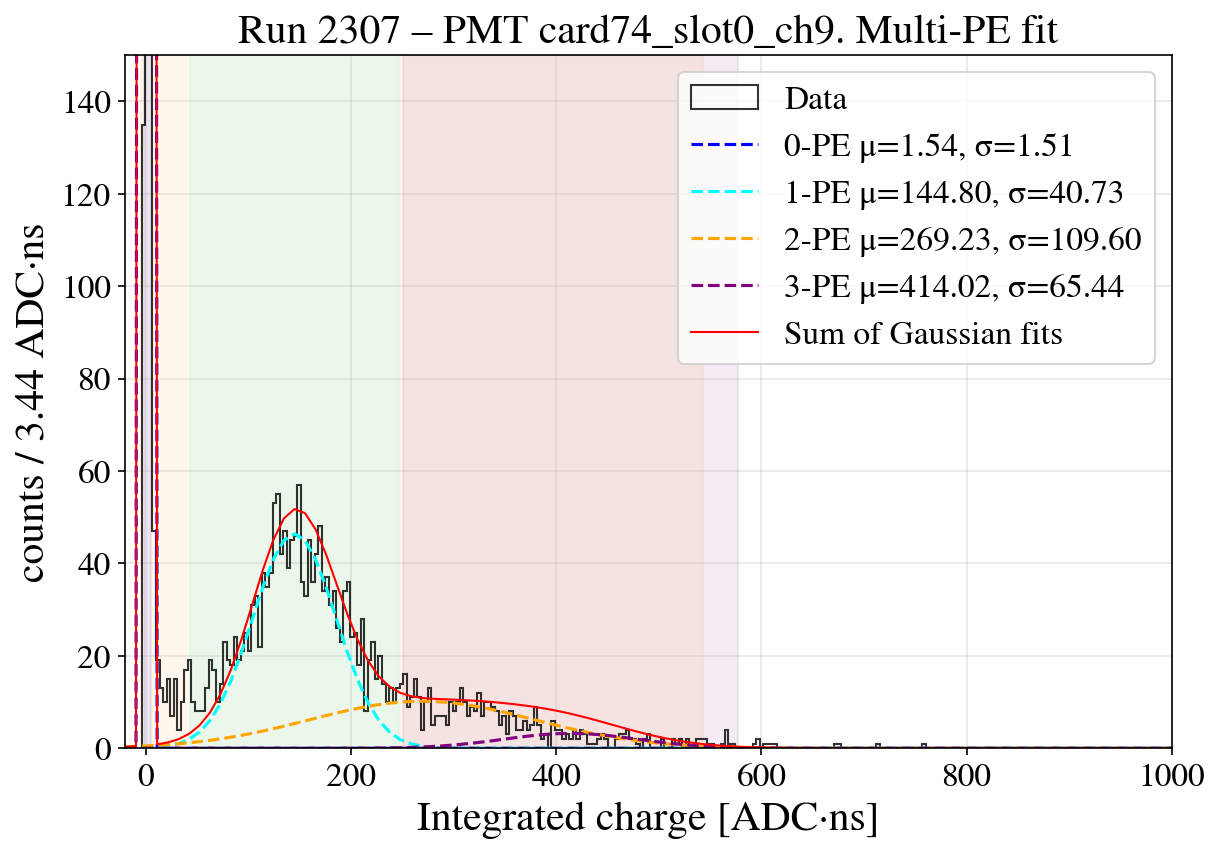


=== FINAL MULTI-PE FIT RESULTS ===
0-PE: mu=1.54, sigma=1.51, N=12606
1-PE: mu=144.80, sigma=40.73, N=4740
2-PE: mu=269.23, sigma=109.60, N=2796
3-PE: mu=414.02, sigma=65.44, N=527

Processing PMT card74_slot0_ch12 with pulse_ratio=0.3282


Integrating waveforms for card74_slot0_ch12: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:00<00:00, 37889.95it/s]


Total waveforms: 6000 | Pulses: 1969 | Noise: 4031 | mu_pe=0.3977
Pedestal: mu=0.80, sigma=1.74
SPE: mu=140.85, sigma=32.23, Gain=139.57 ± inf


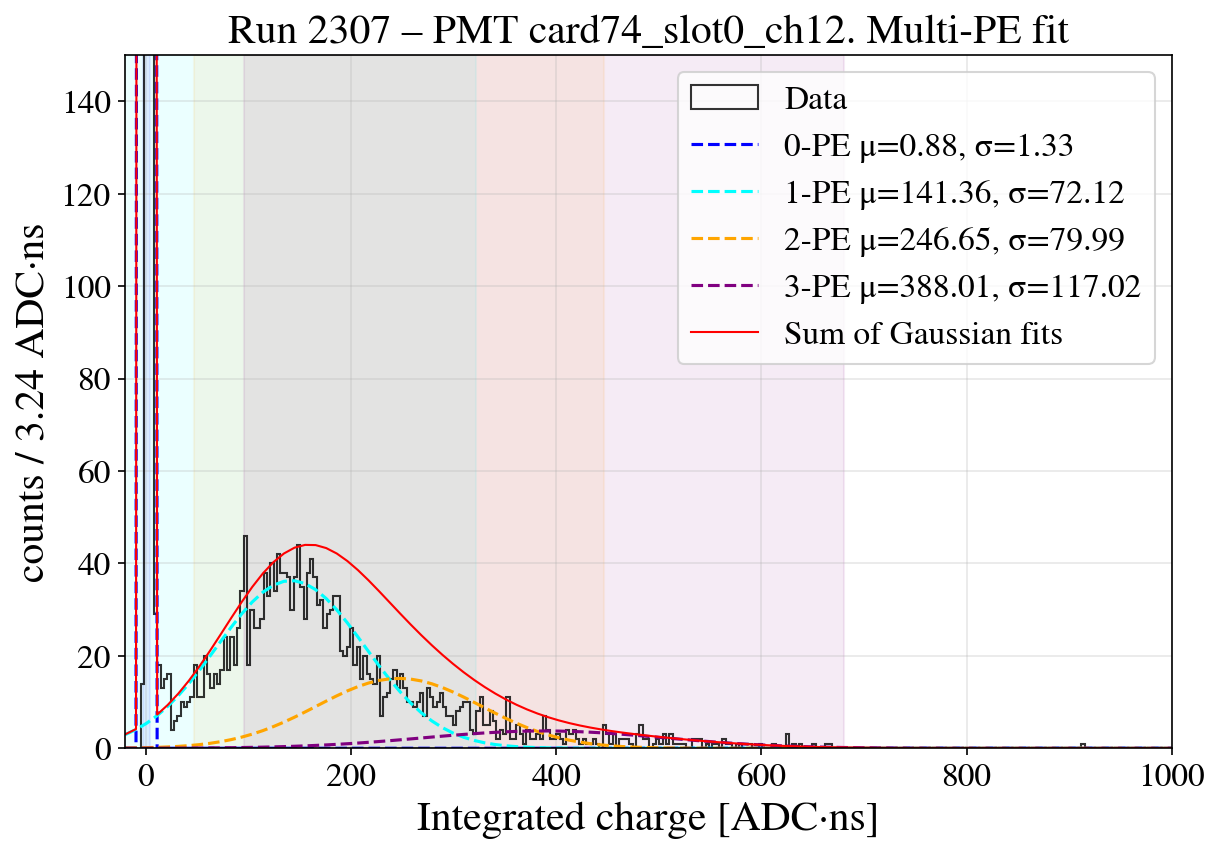


=== FINAL MULTI-PE FIT RESULTS ===
0-PE: mu=0.88, sigma=1.33, N=12504
1-PE: mu=141.36, sigma=72.12, N=6562
2-PE: mu=246.65, sigma=79.99, N=3031
3-PE: mu=388.01, sigma=117.02, N=1098

Processing PMT card74_slot0_ch15 with pulse_ratio=0.3252


Integrating waveforms for card74_slot0_ch15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:00<00:00, 35882.54it/s]


Total waveforms: 6000 | Pulses: 1951 | Noise: 4049 | mu_pe=0.3933
Pedestal: mu=0.80, sigma=1.46
SPE: mu=136.00, sigma=32.29, Gain=135.12 ± inf


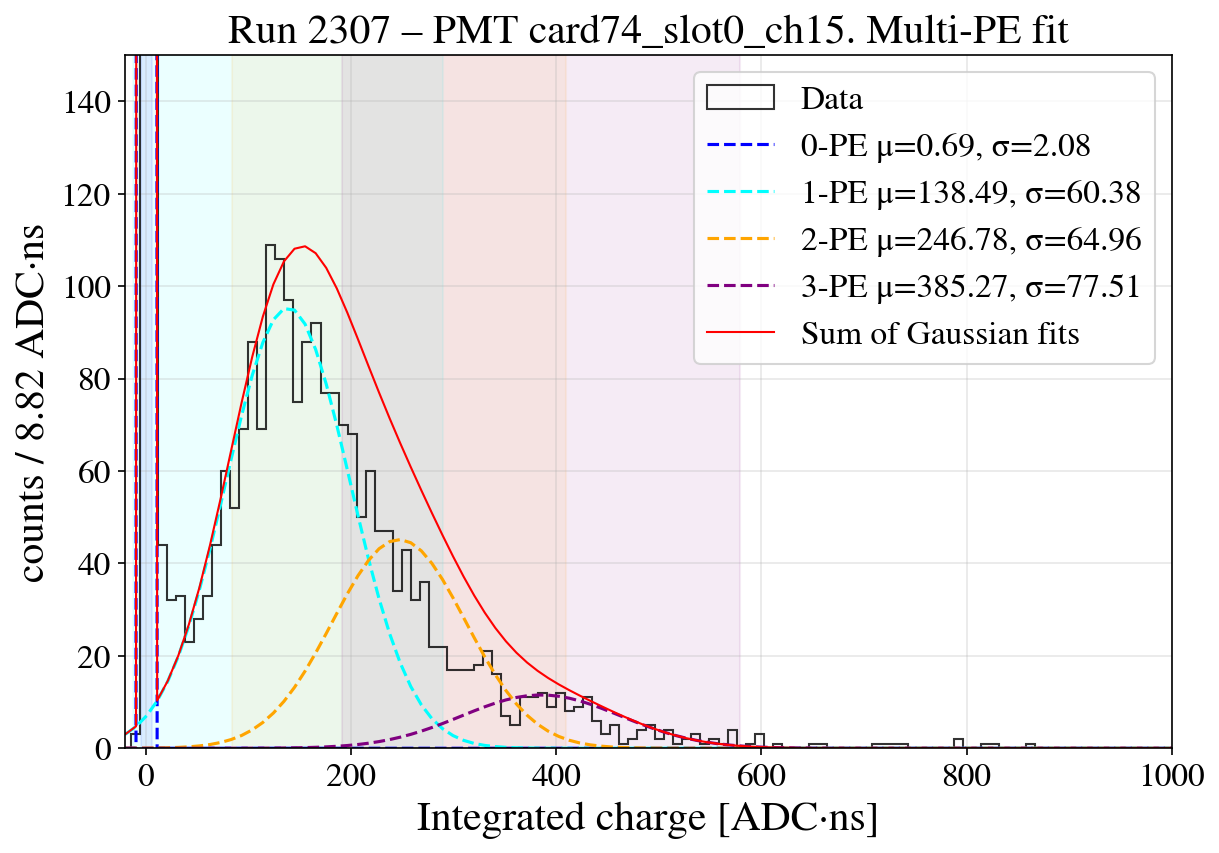


=== FINAL MULTI-PE FIT RESULTS ===
0-PE: mu=0.69, sigma=2.08, N=36826
1-PE: mu=138.49, sigma=60.38, N=14433
2-PE: mu=246.78, sigma=64.96, N=7356
3-PE: mu=385.27, sigma=77.51, N=2241

Processing PMT card82_slot7_ch4 with pulse_ratio=0.3098


Integrating waveforms for card82_slot7_ch4: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:00<00:00, 35941.88it/s]


Total waveforms: 6000 | Pulses: 1859 | Noise: 4141 | mu_pe=0.3708
Pedestal: mu=0.90, sigma=1.67
SPE: mu=138.90, sigma=30.73, Gain=137.14 ± inf


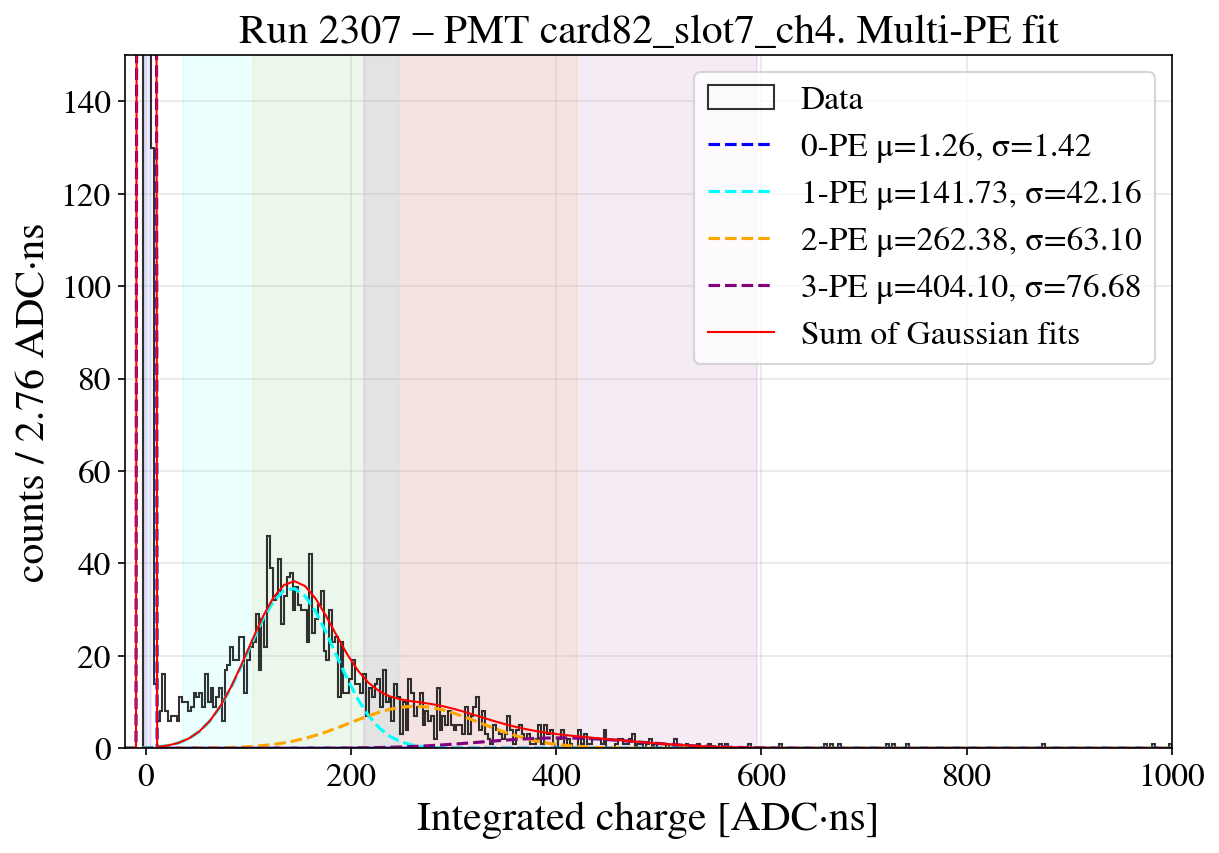


=== FINAL MULTI-PE FIT RESULTS ===
0-PE: mu=1.26, sigma=1.42, N=10644
1-PE: mu=141.73, sigma=42.16, N=3661
2-PE: mu=262.38, sigma=63.10, N=1438
3-PE: mu=404.10, sigma=76.68, N=431

Processing PMT card117_slot5_ch1 with pulse_ratio=0.3038


Integrating waveforms for card117_slot5_ch1: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:00<00:00, 36199.66it/s]


Total waveforms: 6000 | Pulses: 1823 | Noise: 4177 | mu_pe=0.3622
Pedestal: mu=1.20, sigma=1.64
SPE: mu=147.30, sigma=31.31, Gain=145.86 ± inf


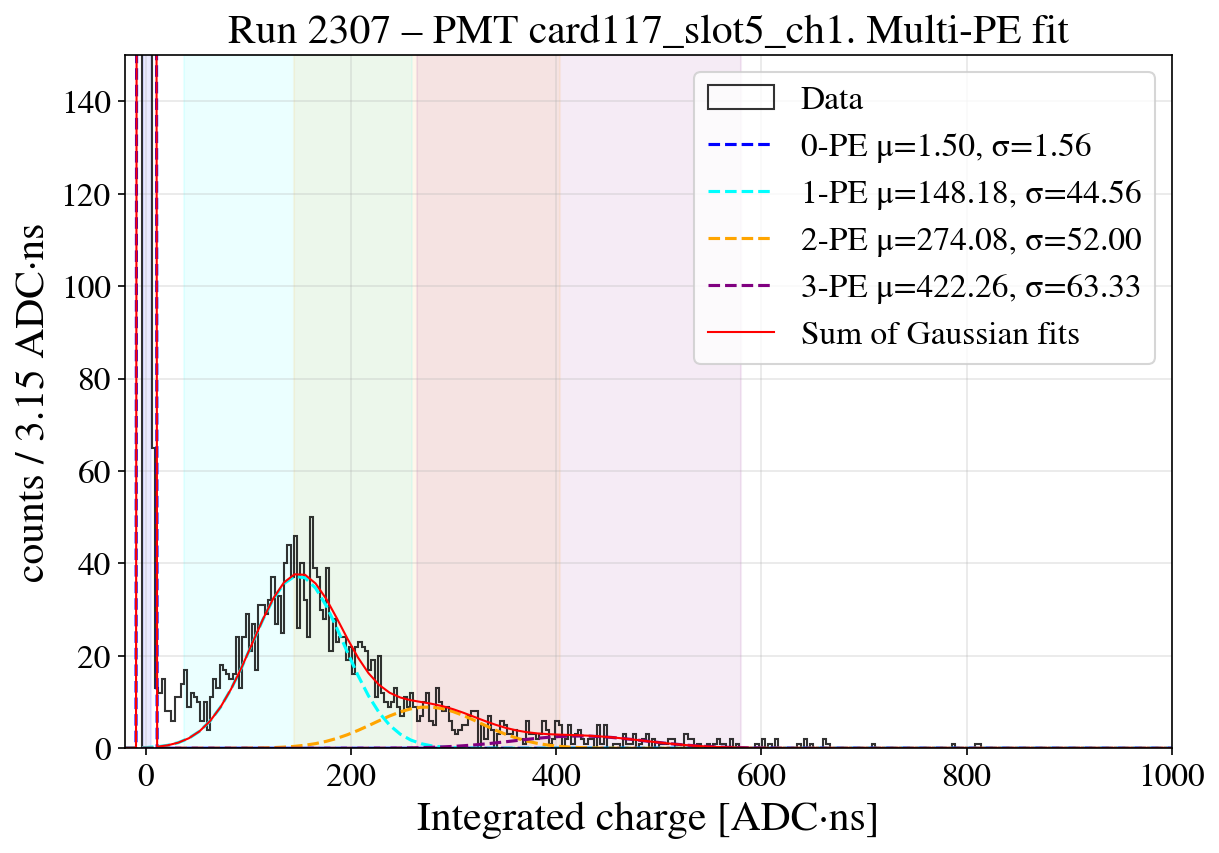


=== FINAL MULTI-PE FIT RESULTS ===
0-PE: mu=1.50, sigma=1.56, N=12344
1-PE: mu=148.18, sigma=44.56, N=4171
2-PE: mu=274.08, sigma=52.00, N=1165
3-PE: mu=422.26, sigma=63.33, N=421


In [8]:
# ==================== PROCESS ALL PMTs ABOVE THRESHOLD ====================
signal_dir = "/scratch/elena/WCTE_DATA_ANALYSIS/waveform_npz/run2307"
pattern = re.compile(r"card(\d+)_slot(\d+)_ch(\d+)_pos(\d+)\.npz$")
PULSE_RATIO_THRESHOLD = 0.3  # roughly corresponds to mu_pe ~ 0.5

available_pmts = []
for fname in os.listdir(signal_dir):
    match = pattern.match(fname)
    if match:
        available_pmts.append(tuple(map(int, match.groups())))
available_pmts = sorted(available_pmts)
print(f"Found {len(available_pmts)} PMT files.")

selected_pmts = []

# ==================== FIRST PASS: FIND ALL PMTs ABOVE THRESHOLD ====================
for card_id, slot_id, ch_id, pos_id in available_pmts:

    combined_file = os.path.join(signal_dir, f"card{card_id}_slot{slot_id}_ch{ch_id}_pos{pos_id}.npz")
    data = np.load(combined_file, allow_pickle=True)
    signal_waveforms = data["waveforms"]

    # Pulse finding
    all_peaks = [do_pulse_finding(wf) for wf in signal_waveforms]
    pulse_mask = np.array([len(p)>0 for p in all_peaks])
    pulse_ratio = np.sum(pulse_mask) / len(signal_waveforms)

    if pulse_ratio >= PULSE_RATIO_THRESHOLD:
        pmt_label = f"card{card_id}_slot{slot_id}_ch{ch_id}"
        selected_pmts.append((pmt_label, signal_waveforms, pulse_ratio))

if not selected_pmts:
    # fallback to brightest PMT
    best_ratio = 0
    best_pmt = None
    for card_id, slot_id, ch_id, pos_id in available_pmts:
        combined_file = os.path.join(signal_dir, f"card{card_id}_slot{slot_id}_ch{ch_id}_pos{pos_id}.npz")
        data = np.load(combined_file, allow_pickle=True)
        signal_waveforms = data["waveforms"]
        all_peaks = [do_pulse_finding(wf) for wf in signal_waveforms]
        pulse_mask = np.array([len(p)>0 for p in all_peaks])
        pulse_ratio = np.sum(pulse_mask) / len(signal_waveforms)
        if pulse_ratio > best_ratio:
            best_ratio = pulse_ratio
            best_pmt = (f"card{card_id}_slot{slot_id}_ch{ch_id}", signal_waveforms, pulse_ratio)
    selected_pmts.append(best_pmt)
    print(f"No PMT reached threshold, fallback to brightest: {best_pmt[0]}, pulse_ratio={best_ratio:.4f}")

# ==================== LOOP OVER SELECTED PMTs ====================
for pmt_label, signal_waveforms, pulse_ratio in selected_pmts:
    print(f"\nProcessing PMT {pmt_label} with pulse_ratio={pulse_ratio:.4f}")

    # Charge calculation
    all_peaks = [do_pulse_finding(wf) for wf in signal_waveforms]
    pulse_mask = np.array([len(p)>0 for p in all_peaks])
    noise_mask = ~pulse_mask

    charges = []
    peak_values = []

    for wf, peaks in tqdm(zip(signal_waveforms, all_peaks), total=len(signal_waveforms), desc=f"Integrating waveforms for {pmt_label}"):
        peak_sample = peaks[0] if len(peaks)>0 else np.argmax(wf)
        charges.append(charge_calculation_mPMT_method(wf, peak_sample))
        peak_values.append(wf[peak_sample])

    charges = np.array(charges)
    peak_values = np.array(peak_values)

    pulse_count = np.sum(pulse_mask)
    noise_count = np.sum(noise_mask)
    mu_pe = -np.log(1 - pulse_ratio)

    run_number = int(re.search(r"run(\d+)", signal_dir).group(1))
    pulse_width = 810

    print(f"Total waveforms: {len(signal_waveforms)} | Pulses: {pulse_count} | Noise: {noise_count} | mu_pe={mu_pe:.4f}")

    # ==================== CALCULATE SEEDS ========================
    seeds = fit_pedestal_and_spe(charges, label=pmt_label, plot=False)
    if seeds is None:
        print(f"Warning: Could not calculate seeds for {pmt_label}, skipping...")
        continue

    print(f"Pedestal: mu={seeds['pedestal']['mu']:.2f}, sigma={seeds['pedestal']['sigma']:.2f}")
    print(f"SPE: mu={seeds['spe']['mu']:.2f}, sigma={seeds['spe']['sigma']:.2f}, Gain={seeds['gain']:.2f} ± {seeds['err_gain']:.2f}")

    # ==================== MULTI-PE FIT & PLOT =====================
    n_max_pe = 3
    multi_pe_results = fit_multi_pe_sequential(charges, seeds, n_max=n_max_pe, bins=500, plot=True)

    # ==================== PRINT RESULTS ===========================
    print("\n=== FINAL MULTI-PE FIT RESULTS ===")
    for n, (mu, sigma, A) in multi_pe_results.items():
        N_events = int(A * sigma * np.sqrt(2*np.pi))
        if N_events > 0:
            print(f"{n}-PE: mu={mu:.2f}, sigma={sigma:.2f}, N={N_events}")